X_train shape: (87554, 187, 1)
X_test shape : (21892, 187, 1)

Class distribution (train):
  Normal: 72471
  Supraventricular: 2223
  Ventricular: 5788
  Fusion: 641
  Unknown: 6431


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 185, 8)              │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 92, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 736)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │          11,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │              85 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,909 (46.52 KB)

 Trainable params: 11,909 (46.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8656 - loss: 0.4846 - val_accuracy: 0.8959 - val_loss: 0.3509
Epoch 2/5
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9109 - loss: 0.3022 - val_accuracy: 0.9242 - val_loss: 0.2677
Epoch 3/5
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9302 - loss: 0.2397 - val_accuracy: 0.9325 - val_loss: 0.2329
Epoch 4/5
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9446 - loss: 0.2046 - val_accuracy: 0.9472 - val_loss: 0.1982
Epoch 5/5
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9511 - loss: 0.1848 - val_accuracy: 0.9515 - val_loss: 0.1844
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9515 - loss: 0.1844

 95.15 %uracy:
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

                  precision    recall  f1-score   support

          Normal       0.95      0.99      0.97     18118
Supraventricular       0.89      0.38      0.53       556
     Ventricular       0.90      0.80      0.85      1448

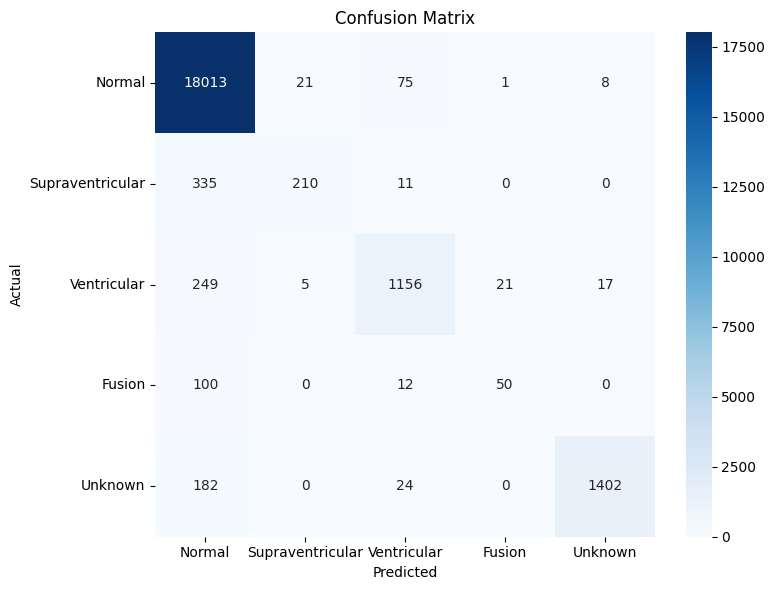

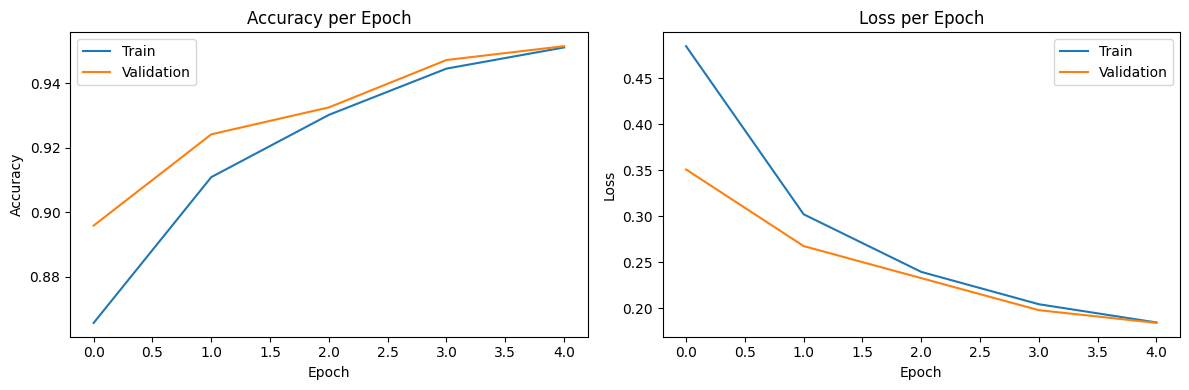

INFO:tensorflow:Assets written to: C:\Users\Hp\AppData\Local\Temp\tmpdp20assu\assets


INFO:tensorflow:Assets written to: C:\Users\Hp\AppData\Local\Temp\tmpdp20assu\assets


Saved artifact at 'C:\Users\Hp\AppData\Local\Temp\tmpdp20assu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2202424193488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2202424194448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2202424194256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2202424194832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2202424194640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2202424195216: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Quantized TFLite model saved!
   Model size: 17.35 KB
✅ model_data.cc generated successfully!
   File size: 107.1 KB
🚀 Ready for ESP32 upload!


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df  = pd.read_csv("mitbih_test.csv", header=None)

X_train        = train_df.iloc[:, :-1].values
y_train_labels = train_df.iloc[:, -1].values.astype(int)

X_test        = test_df.iloc[:, :-1].values
y_test_labels = test_df.iloc[:, -1].values.astype(int)

X_train = X_train.reshape(-1, 187, 1)
X_test  = X_test.reshape(-1, 187, 1)

y_train = to_categorical(y_train_labels, num_classes=5)
y_test  = to_categorical(y_test_labels,  num_classes=5)

CLASS_NAMES = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nClass distribution (train):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {np.sum(y_train_labels == i)}")


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(187, 1)),
    tf.keras.layers.Conv1D(8, 3, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)


loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print("\nTest Accuracy:", round(accuracy * 100, 2), "%")

y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

print()
print(classification_report(y_test_labels, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

with open("ecg_model_int8.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Quantized TFLite model saved!")
print("Model size:", round(os.path.getsize("ecg_model_int8.tflite") / 1024, 2), "KB")


def convert_to_c_array(input_file, output_file):
    with open(input_file, "rb") as f:
        data = f.read()

    with open(output_file, "w") as f:
        f.write("unsigned char ecg_model_int8_tflite[] = {\n")

        for i, byte in enumerate(data):
            f.write(f"0x{byte:02x}, ")
            if (i + 1) % 12 == 0:
                f.write("\n")

        f.write("\n};\n")
        f.write(f"unsigned int ecg_model_int8_tflite_len = {len(data)};\n")

    print("model_data.cc generated successfully!")
    print("File size:", round(os.path.getsize(output_file) / 1024, 2), "KB")

convert_to_c_array("ecg_model_int8.tflite", "model_data.cc")
print("Ready for ESP32 upload!")